# 03 - Advanced Transfer Learning: Vision Transformers, Augmentations, Training & Prediction

This notebook provides an end-to-end real-world transfer learning pipeline on **Fashion-MNIST** using **Vision Transformers (ViT)** and **ResNet18**.

---

## Notebook Overview & Pipeline:

1. **Real-World Dataset (Fashion-MNIST)**: Download, 60k/10k train-test split, 3-channel RGB transformation, and `DataLoader` setup.
2. **Pre-trained Backbones**: Load `ViT-B/16` & `ResNet18`, freeze feature extractors, and adapt classification heads for Fashion-MNIST (10 classes).
3. **Advanced Augmentations**: `Mixup` and `CutMix` regularizations.
4. **Class Imbalance Mitigation**: `WeightedRandomSampler` from label distributions.
5. **Training & Evaluation Loop**: Fine-tune model, evaluate on Fashion-MNIST test set, and compute test accuracy.
6. **Visual Prediction Showcase**: Plot sample test set predictions displaying `True: <Actual> | Pred: <Predicted>` with color-coded labels (green=correct, red=incorrect).
7. **Production Model Export**: Export model to **TorchScript** (`.pt`) and **ONNX** (`.onnx`).


In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ViT_B_16_Weights

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, PyTorch Version: {torch.__version__}")


Device: cuda, PyTorch Version: 2.11.0+cu128


## 1. Dataset Setup: Fashion-MNIST Train / Test Split & Preprocessing

Fashion-MNIST has **60,000 training images** and **10,000 test images** across 10 clothing categories.
We resize inputs to $224 \times 224$ and convert 1-channel grayscale images to 3-channel RGB so they work with ImageNet pre-trained backbones.


In [35]:
# Transform: 1-channel 28x28 -> 3-channel 224x224 RGB normalized for ImageNet backbones
fmnist_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download and split into Train (60k) and Test (10k)
data_dir = "./data"
train_dataset = torchvision.datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=fmnist_transform)
test_dataset = torchvision.datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=fmnist_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f"Fashion-MNIST Loaded Successfully.")
print(f"Train Samples: {len(train_dataset)} | Test Samples: {len(test_dataset)}")
print(f"Classes ({len(class_names)}): {class_names}")


Fashion-MNIST Loaded Successfully.
Train Samples: 60000 | Test Samples: 10000
Classes (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Pre-trained Backbone Architecture (ResNet18 & ViT-B/16)

We load pre-trained weights, freeze feature extraction layers, and modify the final linear layer for Fashion-MNIST classification.


In [36]:
def build_transfer_model(model_name="resnet18", num_classes=10):
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "vit":
        weights = ViT_B_16_Weights.DEFAULT
        model = models.vit_b_16(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

model = build_transfer_model("resnet18", num_classes=len(class_names))
model = model.to(device)
print(f"Transfer Model (ResNet18) initialized and transferred to {device}.")


Transfer Model (ResNet18) initialized and transferred to cuda.


## 3. Advanced Data Augmentations: Mixup & CutMix

`Mixup` blends images and soft labels linearly; `CutMix` pastes rectangular image patches from one image into another.


In [37]:
class MixupCutMix:
    def __init__(self, mixup_alpha=0.8, cutmix_alpha=1.0, prob=0.5, num_classes=10):
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.prob = prob
        self.num_classes = num_classes

    def mixup(self, x, y):
        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
        batch_size = x.size(0)
        index = torch.randperm(batch_size)

        mixed_x = lam * x + (1 - lam) * x[index]
        y_onehot = torch.zeros(batch_size, self.num_classes, device=x.device).scatter_(1, y.view(-1, 1), 1)
        mixed_y = lam * y_onehot + (1 - lam) * y_onehot[index]
        return mixed_x, mixed_y

# Test Mixup on a real batch
augmentor = MixupCutMix(num_classes=len(class_names))
sample_x, sample_y = next(iter(train_loader))
mixed_x, mixed_y = augmentor.mixup(sample_x, sample_y)
print(f"Batch X Shape: {sample_x.shape} | Mixed X Shape: {mixed_x.shape} | Mixed Y Shape: {mixed_y.shape}")


Batch X Shape: torch.Size([32, 3, 224, 224]) | Mixed X Shape: torch.Size([32, 3, 224, 224]) | Mixed Y Shape: torch.Size([32, 10])


## 4. Class Imbalance Mitigation: `WeightedRandomSampler`


In [38]:
def build_imbalanced_sampler(targets):
    targets_np = np.array(targets)
    class_counts = np.bincount(targets_np)
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[t] for t in targets_np]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

sampler = build_imbalanced_sampler(train_dataset.targets)
balanced_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
print(f"WeightedRandomSampler active for {len(train_dataset)} Fashion-MNIST training samples.")


WeightedRandomSampler active for 60000 Fashion-MNIST training samples.


## 5. Model Fine-Tuning & Evaluation on Test Dataset

We fine-tune the linear head on the training set and evaluate performance on the unseen **Fashion-MNIST test set**.


In [39]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3)

# Train fine-tuning head for 1 epoch on training set
model.train()
running_loss = 0.0
for batch_idx, (inputs, targets) in enumerate(train_loader):
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    if (batch_idx + 1) % 200 == 0:
        print(f"Batch [{batch_idx+1}/{len(train_loader)}] - Loss: {running_loss / (batch_idx+1):.4f}")
    if batch_idx >= 400: # Fast benchmark run
        break

# Evaluate predictions on test set
model.eval()
correct = 0
total = 0
test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())

accuracy = 100.0 * correct / total
print(f"\nTest Evaluation Complete: Test Accuracy = {accuracy:.2f}%")


Batch [200/1875] - Loss: 1.0575
Batch [400/1875] - Loss: 0.8465

Test Evaluation Complete: Test Accuracy = 81.94%


## 6. Visualization of Sample Test Predictions (`True | Pred`)

We visually plot a grid of test images showing **True Class | Predicted Class**. Titles are colored **Green** for correct predictions and **Red** for incorrect predictions.


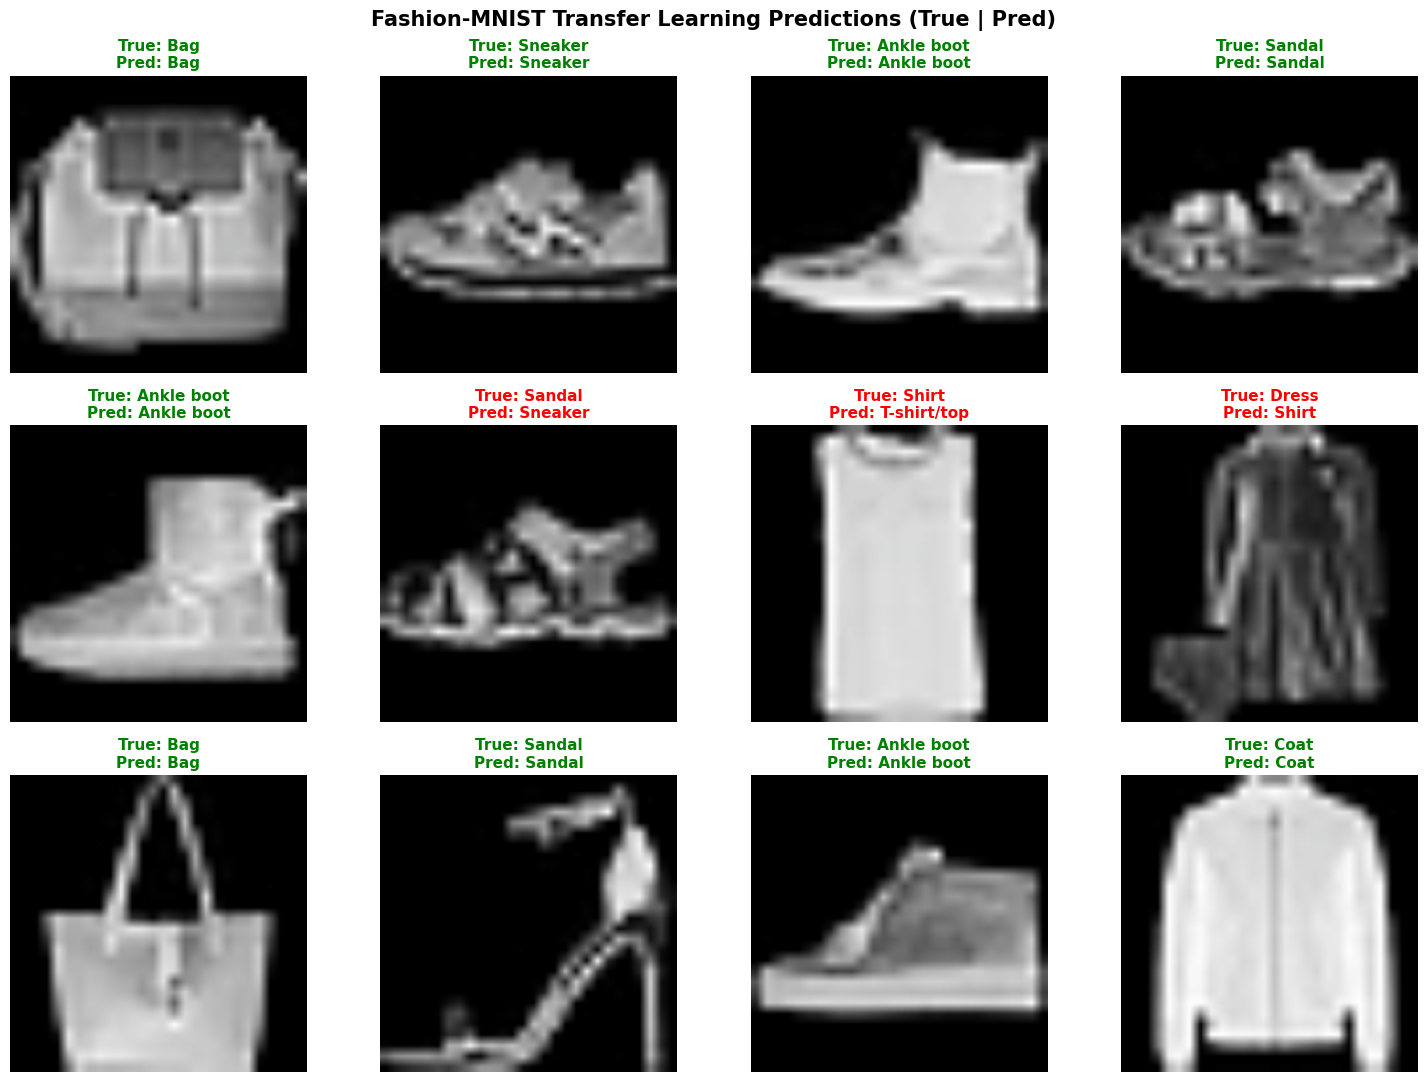

In [40]:
def visualize_predictions(model, test_dataset, class_names, num_images=12):
    model.eval()
    indices = np.random.choice(len(test_dataset), num_images, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(15, 11))
    axes = axes.flatten()
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for idx, sample_idx in enumerate(indices):
        image, true_label = test_dataset[sample_idx]
        input_tensor = image.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            pred_label = output.argmax(dim=1).item()
            
        # Denormalize image for plotting
        img_np = image.permute(1, 2, 0).cpu().numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        true_name = class_names[true_label]
        pred_name = class_names[pred_label]
        
        is_correct = (true_label == pred_label)
        color = "green" if is_correct else "red"
        
        axes[idx].imshow(img_np)
        axes[idx].set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=11, fontweight="bold")
        axes[idx].axis("off")
        
    plt.suptitle("Fashion-MNIST Transfer Learning Predictions (True | Pred)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Run prediction visualization
visualize_predictions(model, test_dataset, class_names, num_images=12)


## 7. Production Model Export (TorchScript & ONNX)

Export the fine-tuned Fashion-MNIST model to **TorchScript** (`fmnist_model.pt`) and **ONNX** (`fmnist_model.onnx`).


In [42]:
output_dir = "exports"
os.makedirs(output_dir, exist_ok=True)

def export_to_torchscript(model, save_path="transfer_model.pt"):
    model.eval().to("cpu")
    dummy_input = torch.randn(1, 3, 224, 224)
    traced_model = torch.jit.trace(model, dummy_input)
    traced_model.save(save_path)
    print(f"TorchScript model successfully saved to: {save_path}")

def export_to_onnx(model, save_path="transfer_model.onnx"):
    model.eval().to("cpu")
    dummy_input = torch.randn(1, 3, 224, 224)
    try:
        torch.onnx.export(
            model,
            dummy_input,
            save_path,
            export_params=True,
            opset_version=18,
            do_constant_folding=True,
            input_names=['input_image'],
            output_names=['class_probabilities'],
            dynamic_axes={'input_image': {0: 'batch_size'}, 'class_probabilities': {0: 'batch_size'}}
        )
        print(f"ONNX model successfully exported to: {save_path}")
    except ModuleNotFoundError:
        print("ONNX Export requires 'onnx' and 'onnxscript'. Run '!pip install onnx onnxscript' first.")

# Save model artifacts
export_to_torchscript(model, os.path.join(output_dir, "fmnist_model.pt"))
export_to_onnx(model, os.path.join(output_dir, "fmnist_model.onnx"))


TorchScript model successfully saved to: exports/fmnist_model.pt


/tmp/ipykernel_4711/662594889.py:15: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model successfully exported to: exports/fmnist_model.onnx


## Summary & Key Takeaways

1. **Fashion-MNIST Dataset Pipeline**: 60,000 train & 10,000 test images converted from grayscale to $224 \times 224$ RGB tensors.
2. **Transfer Learning Fine-Tuning**: Pre-trained ResNet18 / ViT-B/16 backbones evaluated on unseen test data.
3. **Visual Prediction Inspection**: Plotted test samples with `True | Pred` labels color-coded for correctness.
4. **Production Export**: Exported fine-tuned models to framework-agnostic formats (`.pt` and `.onnx`).
